## Predictive Analytics for Healthcare Claims: Identifying Cost Patterns, Fraud, and Outcomes


# Background, Data, and Problem Definition

Healthcare claims data is essential in understanding healthcare services and its financial
systems. When a patient receives medical service, the healthcare provider (hospital, clinic,
doctor, etc) submits a claim to an insurance company (Medicare, private insurance, etc) in
hopes of receiving reimbursement for the requested services. The insurance company or
payer then reviews the claim to determine whether the patient meets the specified criteria
for reimbursement.

## Healthcare Claims Dataset
The [data](https://www.kaggle.com/datasets/abuthahir1998/synthetic-healthcare-claims-dataset) comprises of one file "claims.csv" containing 15 columns and 1000 rows of data.

Below represents the following information for the columns.

### Synthetic Healthcare Claims Dataset Columns

| Column                      | Definition                                                                                      |
|-----------------------------|------------------------------------------------------------------------------------------------|
| Claim ID                    | Unique identifier for each claim.                                                              |
| Provider ID                 | Unique identifier for the healthcare provider submitting the claim.                            |
| Patient ID                  | Unique identifier for the patient (randomly generated).                                       |
| Date of Service             | The date when the healthcare service was provided.                                            |
| Billed Amount               | The total amount billed by the provider.                                                      |
| Procedure Code (CPT/HCPCS)  | The code representing the medical procedure or service rendered.                              |
| Diagnosis Code (ICD-10)     | International Classification of Diseases code representing the patient’s diagnosis.           |
| Charge Amount               | The total amount billed for the service by the provider.                                      |
| Paid Amount                 | The amount paid by the insurer or patient for the claim.                                      |
| Insurance Type              | The type of insurance coverage (e.g., Private, Medicare, Medicaid).                           |
| Claim Status                | The current status of the claim (e.g., Paid, Denied, Partially Paid).                         |
| Reason Code                 | Code representing the reason for claim denial or payment adjustment.                          |
| Follow-up Required          | Indicates whether follow-up actions are required to resolve the claim.                        |
| AR Status                   | Accounts Receivable status for the claim (e.g., Open, Closed).                                |
| Outcome                     | Final outcome of the claim (e.g., Paid, Denied, Partial).                                     |

The dataset chosen for this project is synthetic, mimicking real-world medical claim structures. Such structures include procedure codes, diagnosis codes, and various payment information. The synthetic nature of the dataset allows for safe exploration of healthcare claims research without any risk of privacy concerns.

                                 
# Project Definition

Beyond insurance companies' processing payments, claims data provides critical insights
into healthcare claims delivery and utilization. There is also the possibility of potential
fraud and inefficient resource allocation. Healthcare claims is one of the most lucrative
industries that has the potential to utilize data mining and predictive modeling to address all these challenges and
problems as specified below.
This project utilizes a synthetic healthcare claims dataset to explore the following key
topics:

#### 1. Cost Patterns: 
Identify trends in billing, allowed amounts, and payment behaviors across features to uncover inefficiencies or cost discrepensies. 

#### 2. Fraud Detection:  
Detect anomalous patterns in claims submissions, such as unusual billing behaviors, suggesting fraudulent activities.

#### 3. Claims Outcome Prediction: 
Build predictive models to forecast the outcome status of healthcare claims based on historical data and engineered features.

#### This project aims to support claim insurers and reviews to better understand claim behavior, improving decision-making while reducing financial risk.

# Methodology

### METHODOLOGY:
To address the key objectives of cost pattern analysis, fraud detection, and claims outcome prediction, various data mining techniques will be applied, particularly through predictive modeling.  

The project workflow consists of the following main steps:

#### 1. Data Pre-Processing/ Exploratory Data Analysis(EDA) 
**Objective:** Ensure data quality and consistency for effective analysis.  
- Load and explore the dataset to assess structure, completeness, and potential issues.  
- Explore skewness and distribution of financial columns to understand patterns and discrepancies.
- Engineered key ratio-based features such as Billed_to_Allowed_Ratio, Allowed_to_Paid_Ratio, and Payment_Ratio.

#### 2. Baseline Models
**Objective:** Establish a baseline performance utilizing various models to predict claims outcomes(target).  
- **Logistic Regression:** Train and evaluate a logistic regression model as the baseline model. 
- **Random Forest Classifier:** Utlize Random Forest classifier as a baseline model in conjunction with Logistic Regression to establish initial performance benchmarks.
- Evaluating model performance using accuracy, precision, recall, and F1-score along with feature importance metrics.

#### 3. Class Imbalance Handling
**Objective:** Handle class imbalances (if present) to improve model performance across multiple classes.
- **SMOTE:** Apply Synthetic Minority Oversampling Technique(SMOTE) to address class imbalances by balancing classes within the target variable, improving model generalization.

#### 4. Modeling with XGBoost
- Implement XGBoost to improve performance over the baseline models that yield the best performance.
- Conducted hyperparameter tuning using GridSearchCV for optimal configurations.

#### 5. Feature Selection & Interpretability
- Used SHAP to visualize how specific features influence predictions, specifically financial ratio features that were key drivers in classifying claim outcomes.

# Data Preprocessing & Overview

In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading in dataset 
df = pd.read_csv('claim_data.csv')

# Exploring first 5 rows of the imported dataframe
df.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


In [3]:
# Checking how many rows,columns,non-null count and data types are within the dataframe
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim ID            1000 non-null   object
 1   Provider ID         1000 non-null   int64 
 2   Patient ID          1000 non-null   int64 
 3   Date of Service     1000 non-null   object
 4   Billed Amount       1000 non-null   int64 
 5   Procedure Code      1000 non-null   int64 
 6   Diagnosis Code      1000 non-null   object
 7   Allowed Amount      1000 non-null   int64 
 8   Paid Amount         1000 non-null   int64 
 9   Insurance Type      1000 non-null   object
 10  Claim Status        1000 non-null   object
 11  Reason Code         1000 non-null   object
 12  Follow-up Required  1000 non-null   object
 13  AR Status           1000 non-null   object
 14  Outcome             1000 non-null   object
dtypes: int64(6), object(9)
memory usage: 117.3+ KB


Claim ID              0
Provider ID           0
Patient ID            0
Date of Service       0
Billed Amount         0
Procedure Code        0
Diagnosis Code        0
Allowed Amount        0
Paid Amount           0
Insurance Type        0
Claim Status          0
Reason Code           0
Follow-up Required    0
AR Status             0
Outcome               0
dtype: int64

#### There are no missing and null  values. All d-type columns correspond with their respective data except for the "Date of Service" column, which needs to be turned from an "object" to "datetime".

In [4]:
# Converting Date of Service from object to Datetime (Normalized)
df['Date of Service'] = pd.to_datetime(df['Date of Service'])

df['Date of Service'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Date of Service
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


In [5]:
# Checking any duplicated values in Claim/Provider ID
df.duplicated(subset=['Claim ID', 'Provider ID']).sum()

0

In [6]:
# Checking statistical measures for outliers
df.describe()

,Provider ID,Patient ID,Billed Amount,Procedure Code,Allowed Amount,Paid Amount
count,1.000000e+03,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000
mean,4.909473e+09,5.112327e+09,297.19100,99223.969000,223.112000,200.754000
std,2.866473e+09,2.919255e+09,116.36365,8.390736,90.784731,83.353688
min,5.364682e+06,9.455298e+06,100.00000,99213.000000,64.000000,53.000000
25%,2.460360e+09,2.600572e+09,197.00000,99215.000000,147.750000,133.000000
50%,5.002762e+09,5.216802e+09,297.00000,99222.000000,225.000000,200.000000
75%,7.313899e+09,7.753702e+09,395.00000,99232.000000,289.000000,262.000000
max,9.991056e+09,9.964057e+09,500.00000,99238.000000,442.000000,423.000000


In [7]:
df[['Insurance Type', 'Claim Status', 'Follow-up Required', 'AR Status','Outcome']].nunique()

Insurance Type        4
Claim Status          3
Follow-up Required    2
AR Status             6
Outcome               3
dtype: int64

In [8]:
categorical_cols =['Insurance Type','Claim Status','Follow-up Required','AR Status','Outcome']

# standardizing categorical text columns to lowercase 
df[categorical_cols] =df[categorical_cols].apply(lambda x: x.str.strip().str.lower())

# checking unique values in each categorical column
for col in categorical_cols:
    print(f'{col}: {df[col].unique()}')

Insurance Type: ['self-pay' 'medicare' 'commercial' 'medicaid']
Claim Status: ['paid' 'under review' 'denied']
Follow-up Required: ['yes' 'no']
AR Status: ['pending' 'open' 'denied' 'partially paid' 'on hold' 'closed']
Outcome: ['partially paid' 'denied' 'paid']


In [9]:
# Creating new column "Payment Ratio" - how much billed amount was actually paid
df['Payment Ratio'] = df['Paid Amount']/df['Billed Amount']

df['Payment Ratio']

0      0.667763
1      0.591954
2      0.506383
3      0.616071
4      0.637931
         ...   
995    0.693811
996    0.660000
997    0.585938
998    0.578652
999    0.706294
Name: Payment Ratio, Length: 1000, dtype: float64

# Exploratory Data Analysis (EDA)

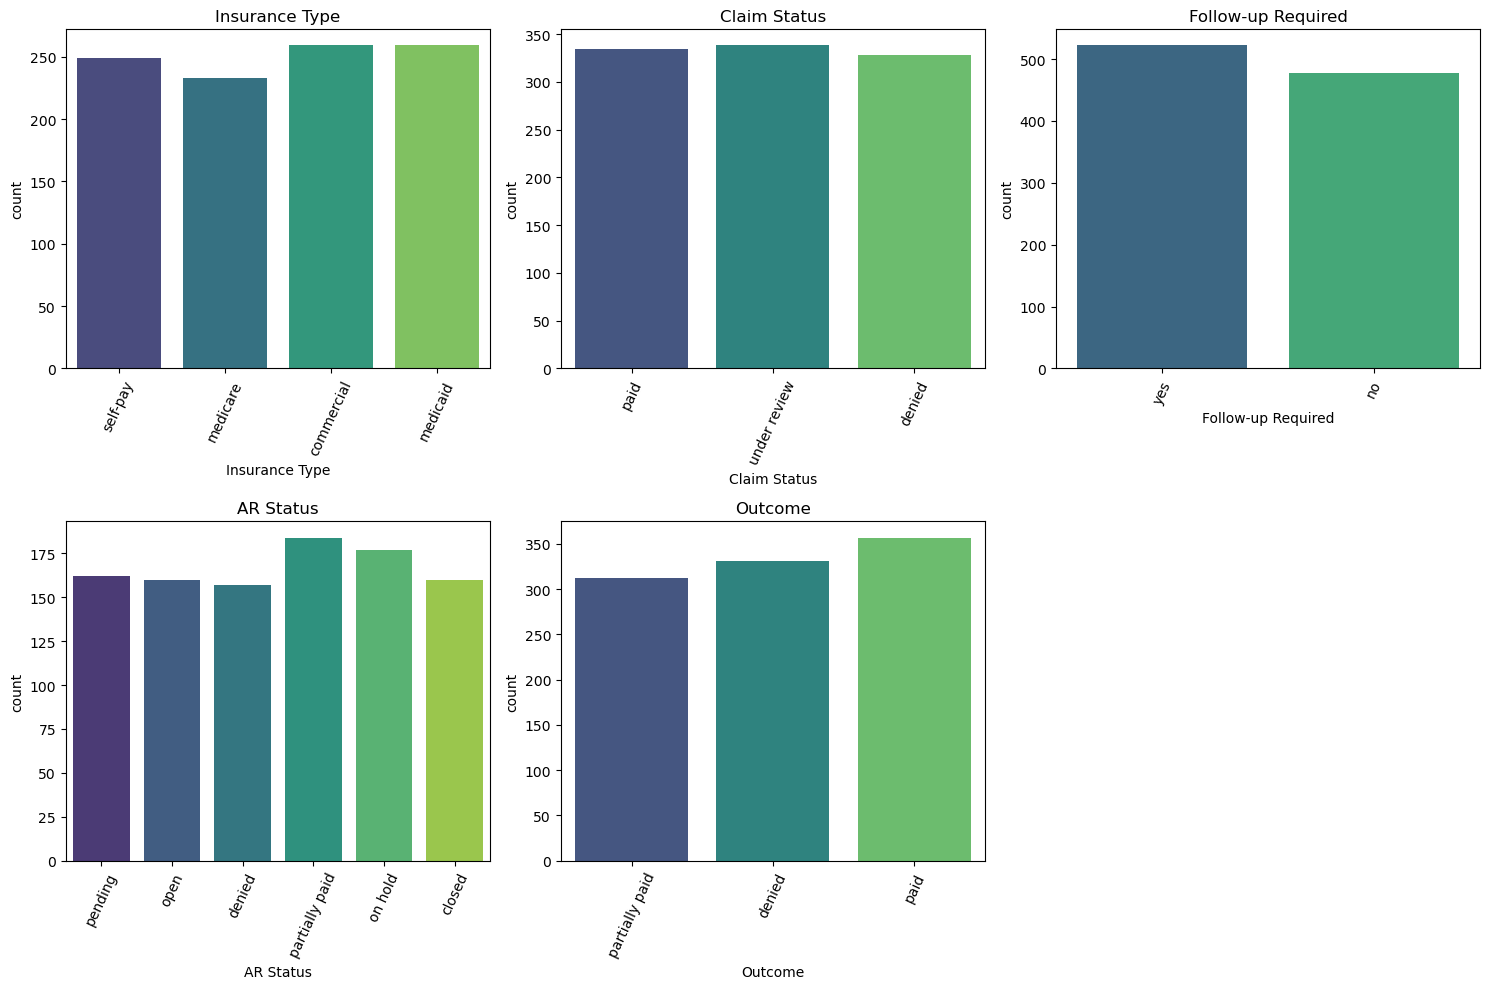

commercial    0.259
medicaid      0.259
self-pay      0.249
medicare      0.233
Name: Insurance Type, dtype: float64

under review    0.338
paid            0.334
denied          0.328
Name: Claim Status, dtype: float64

yes    0.522
no     0.478
Name: Follow-up Required, dtype: float64

partially paid    0.184
on hold           0.177
pending           0.162
open              0.160
closed            0.160
denied            0.157
Name: AR Status, dtype: float64

paid              0.357
denied            0.331
partially paid    0.312
Name: Outcome, dtype: float64



In [10]:
# Visualizing categorical features
plt.figure(figsize=(15, 10))

# i - subplot, col- colname
for i,col in enumerate(categorical_cols,1):
    plt.subplot(2,3,i)
    sns.countplot(data = df,x = col,palette='viridis')
    plt.title(f'{col}')
    plt.xticks(rotation=65)

plt.tight_layout()
plt.show()

# percentage of categorical features
for col in categorical_cols:
    print(df[col].value_counts(normalize=True))
    print()

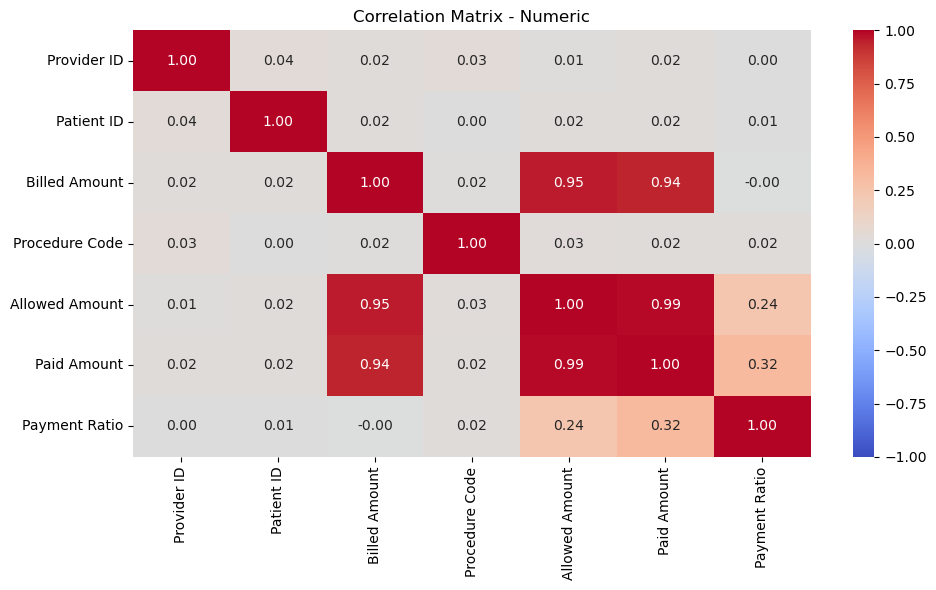

In [11]:
# correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include='number')

# heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(),annot=True,fmt=".2f", cmap='coolwarm',vmin =-1,vmax=1 )
plt.title('Correlation Matrix - Numeric')

plt.tight_layout()
plt.show()

#### Billed Amount - Allowed
#### Billed Amount - Paid
#### Allowed - Paid
#### All are highly correlated.

In [12]:
# Relationship between payment ratio vs categorical features

# average payment ratio of each categorical column
for col in categorical_cols:
    print(f"\nAverage Payment Ratio by {col.title()}:\n")
    print(round(df.groupby(col)['Payment Ratio'].mean(),3))


Average Payment Ratio by Insurance Type:

Insurance Type
commercial    0.676
medicaid      0.678
medicare      0.673
self-pay      0.675
Name: Payment Ratio, dtype: float64

Average Payment Ratio by Claim Status:

Claim Status
denied          0.674
paid            0.681
under review    0.672
Name: Payment Ratio, dtype: float64

Average Payment Ratio by Follow-Up Required:

Follow-up Required
no     0.674
yes    0.677
Name: Payment Ratio, dtype: float64

Average Payment Ratio by Ar Status:

AR Status
closed            0.680
denied            0.677
on hold           0.666
open              0.679
partially paid    0.680
pending           0.673
Name: Payment Ratio, dtype: float64

Average Payment Ratio by Outcome:

Outcome
denied            0.684
paid              0.666
partially paid    0.678
Name: Payment Ratio, dtype: float64


#### All payment ratios are "consistent" across the majority of categories

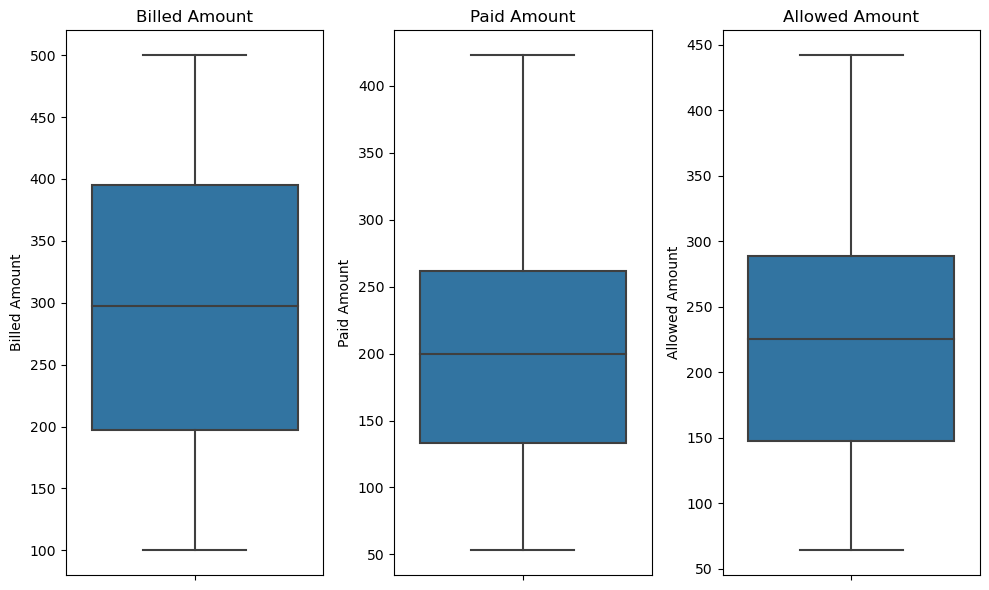

In [13]:
# Checking spread/outliers/skewness of data
fig,axes = plt.subplots(1,3, figsize=(10, 6))

# Boxplot
sns.boxplot(y=df['Billed Amount'],ax=axes[0]).set_title('Billed Amount')
sns.boxplot(y=df['Paid Amount'],ax=axes[1]).set_title('Paid Amount')
sns.boxplot(y=df['Allowed Amount'],ax=axes[2]).set_title('Allowed Amount')

plt.tight_layout()
plt.show()

#### No outliers are present

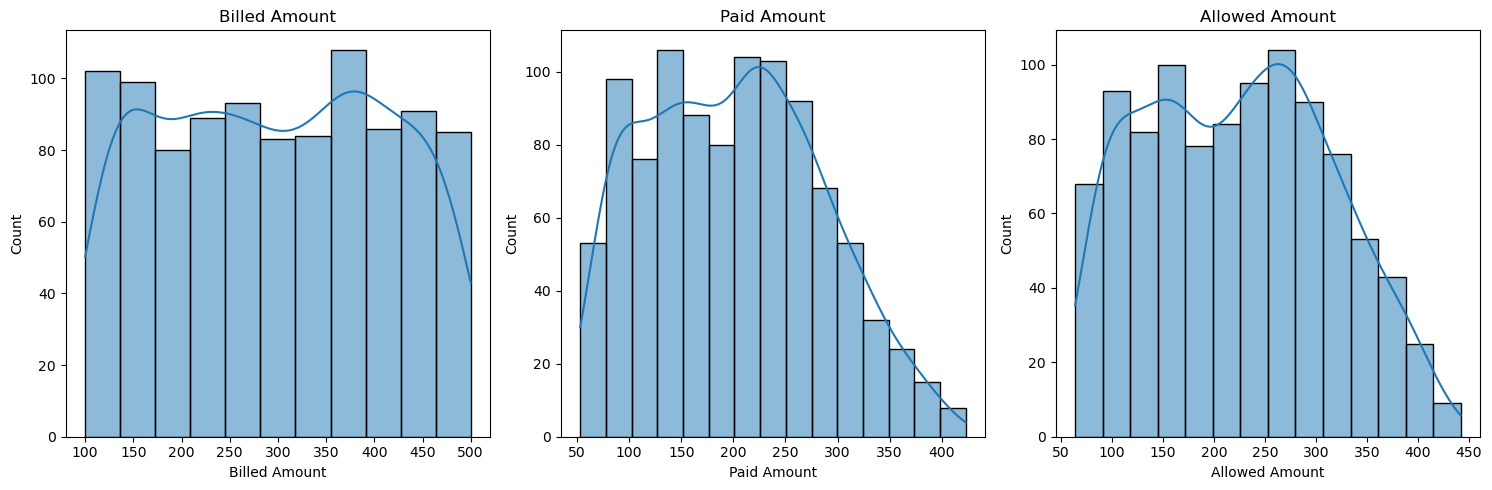

Billed Amount     0.003661
Paid Amount       0.247252
Allowed Amount    0.147553
dtype: float64

In [14]:
# Checking skewness of data 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram with KDE plot
sns.histplot(df['Billed Amount'],ax=axes[0], kde=True).set_title('Billed Amount')
sns.histplot(df['Paid Amount'],ax=axes[1], kde=True).set_title('Paid Amount')
sns.histplot(df['Allowed Amount'],ax=axes[2], kde=True).set_title('Allowed Amount')

plt.tight_layout()
plt.show()

# Skewness Values
df[['Billed Amount', 'Paid Amount', 'Allowed Amount']].skew()

#### Low Skewness

# Categorical Encoding/Feature Engineering

In [15]:
# Checking class distribution
print("Target variable distribution")
print(round(df['Outcome'].value_counts(normalize=True),2))

Target variable distribution
paid              0.36
denied            0.33
partially paid    0.31
Name: Outcome, dtype: float64


In [16]:
# One-hot encoding/ dropping first level to prevent multicollinearity 
df_encoded = pd.get_dummies(df, columns=categorical_cols,drop_first=True)
df_encoded.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Reason Code,...,Claim Status_paid,Claim Status_under review,Follow-up Required_yes,AR Status_denied,AR Status_on hold,AR Status_open,AR Status_partially paid,AR Status_pending,Outcome_paid,Outcome_partially paid
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,Incorrect billing information,...,1,0,1,0,0,0,0,1,0,1
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,Pre-existing condition,...,1,0,1,0,0,1,0,0,0,0
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,Duplicate claim,...,0,1,0,1,0,0,0,0,0,0
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,Authorization not obtained,...,0,0,0,0,0,0,1,0,0,0
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,Authorization not obtained,...,0,0,0,0,1,0,0,0,0,0


In [17]:
# Dropping irrelevant columns for modeling that may introduce noise
cols_to_drop = ['Claim ID', 'Patient ID', 'Provider ID', 'Procedure Code', 'Diagnosis Code']
df_model = df.drop(columns=cols_to_drop)

# Confirm change
print(df_model.columns.tolist())

['Date of Service', 'Billed Amount', 'Allowed Amount', 'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code', 'Follow-up Required', 'AR Status', 'Outcome', 'Payment Ratio']


In [18]:
# Extracting Features from 'Date of Service' - sesonal patterns
df_model['Service_Year'] = pd.to_datetime(df_model['Date of Service']).dt.year
df_model['Service_Month'] = pd.to_datetime(df_model['Date of Service']).dt.month
df_model['Service_Day'] = pd.to_datetime(df_model['Date of Service']).dt.day

# Dropping original Date of Service
df_model = df_model.drop(columns=['Date of Service'])

# Confirm change
print(df_model.columns.tolist())

['Billed Amount', 'Allowed Amount', 'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code', 'Follow-up Required', 'AR Status', 'Outcome', 'Payment Ratio', 'Service_Year', 'Service_Month', 'Service_Day']


In [19]:
# Creating Financial Ratio Features
df_model['Billed_to_Allowed_Ratio'] = df_model['Billed Amount'] / df_model['Allowed Amount']
df_model['Allowed_to_Paid_Ratio'] = df_model['Allowed Amount'] / df_model['Paid Amount']

# Dropping 'Paid Amount' - high correlation with 'Allowed Amount'
df_model = df_model.drop(columns=['Paid Amount'])

# Confirm change
print(df_model.columns.tolist())

['Billed Amount', 'Allowed Amount', 'Insurance Type', 'Claim Status', 'Reason Code', 'Follow-up Required', 'AR Status', 'Outcome', 'Payment Ratio', 'Service_Year', 'Service_Month', 'Service_Day', 'Billed_to_Allowed_Ratio', 'Allowed_to_Paid_Ratio']


In [20]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

# Label encoding target variable (Outcome)
le = LabelEncoder()
df_model['Outcome'] = le.fit_transform(df_model['Outcome'])
print(le.classes_)

# One-hot encoding remaining categorical features
cat_features = ['Insurance Type','Claim Status','Reason Code','Follow-up Required','AR Status']
df_model = pd.get_dummies(df_model, columns=cat_features,drop_first=True)

# Feature Scaling for numerical features
num_features = ['Billed Amount','Allowed Amount','Billed_to_Allowed_Ratio','Allowed_to_Paid_Ratio','Service_Year','Service_Month', 'Service_Day']
scaler = StandardScaler()
df_model[num_features] = scaler.fit_transform(df_model[num_features])

# final shaspe
print("\nFinal Feature Set Shape:", df_model.shape)
print("\nFeature Columns for Modeling:")
print(df_model.columns.tolist())

['denied' 'paid' 'partially paid']

Final Feature Set Shape: (1000, 27)

Feature Columns for Modeling:
['Billed Amount', 'Allowed Amount', 'Outcome', 'Payment Ratio', 'Service_Year', 'Service_Month', 'Service_Day', 'Billed_to_Allowed_Ratio', 'Allowed_to_Paid_Ratio', 'Insurance Type_medicaid', 'Insurance Type_medicare', 'Insurance Type_self-pay', 'Claim Status_paid', 'Claim Status_under review', 'Reason Code_Duplicate claim', 'Reason Code_Incorrect billing information', 'Reason Code_Lack of medical necessity', 'Reason Code_Missing documentation', 'Reason Code_Patient eligibility issues', 'Reason Code_Pre-existing condition', 'Reason Code_Service not covered', 'Follow-up Required_yes', 'AR Status_denied', 'AR Status_on hold', 'AR Status_open', 'AR Status_partially paid', 'AR Status_pending']


# Baseline Model (Logistic Regression & Random Forest)

In [21]:
from sklearn.model_selection import train_test_split

# X = Features y = target
X = df_model.drop(columns=['Outcome'])
y = df_model['Outcome']

# Splitting data (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# X train/test shape
print(f"Training set shape:{X_train.shape}, Testing set shape:{X_test.shape}")

Training set shape:(800, 26), Testing set shape:(200, 26)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Models
log_reg_base = LogisticRegression(class_weight='balanced', random_state=42)
rf_base = RandomForestClassifier(class_weight="balanced", random_state=42)

# Train models on dataset 
log_reg_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

# Predictions on test set
y_pred_log_base = log_reg_base.predict(X_test)
y_pred_rf_base = rf_base.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

# Evaluation 
print("Baseline Logistic Regression Performance:\n", classification_report(y_test, y_pred_log_base))
print("Baseline Random Forest Performance:\n", classification_report(y_test, y_pred_rf_base))

Baseline Logistic Regression Performance:
               precision    recall  f1-score   support

           0       0.32      0.38      0.35        66
           1       0.43      0.32      0.37        72
           2       0.26      0.29      0.27        62

    accuracy                           0.33       200
   macro avg       0.34      0.33      0.33       200
weighted avg       0.34      0.33      0.33       200

Baseline Random Forest Performance:
               precision    recall  f1-score   support

           0       0.29      0.30      0.30        66
           1       0.30      0.31      0.30        72
           2       0.28      0.26      0.27        62

    accuracy                           0.29       200
   macro avg       0.29      0.29      0.29       200
weighted avg       0.29      0.29      0.29       200



#### Train/Test Split - 80/20 split 
#### Training set shape: (800, 26), Testing set shape: (200, 26)
#### Class imbalance - Paid: 36%, Partially Paid:31%, Denied:33%

### Logistic Regression (Baseline)
#### Overall Accuracy - 33%
#### Model struggles across all classes

### Random Forest (Baseline)
#### Overall Accuracy - 29%
#### Slightly worse than Logistic Regression, but can be enhanced with hyperparameter tuning.

# Baseline Model (Logistic Regression & Random Forest) with SMOTE

In [24]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE - training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print("Class distribution after SMOTE:\n",y_train_smote.value_counts(normalize=True))

Class distribution after SMOTE:
 0    0.333333
2    0.333333
1    0.333333
Name: Outcome, dtype: float64


#### Distribution is balanced.

In [25]:
# Models
log_reg = LogisticRegression(class_weight='balanced',random_state=42)
rf = RandomForestClassifier(class_weight="balanced",random_state=42)

# Train models SMOTE
log_reg.fit(X_train_smote, y_train_smote)
rf.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [26]:
# Evaluation(After SMOTE)
print("SMOTE Logistic Regression Performance:\n", classification_report(y_test, y_pred_log))
print("SMOTE Random Forest Performance:\n", classification_report(y_test, y_pred_rf))

SMOTE Logistic Regression Performance:
               precision    recall  f1-score   support

           0       0.35      0.42      0.38        66
           1       0.40      0.38      0.39        72
           2       0.23      0.19      0.21        62

    accuracy                           0.34       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.33      0.34      0.33       200

SMOTE Random Forest Performance:
               precision    recall  f1-score   support

           0       0.38      0.45      0.41        66
           1       0.41      0.33      0.37        72
           2       0.40      0.40      0.40        62

    accuracy                           0.40       200
   macro avg       0.40      0.40      0.39       200
weighted avg       0.40      0.40      0.39       200



### Logistic Regression
#### Recall and f1-score improved for class 0 (denied) and 1 (paid) with SMOTE.
#### Still struggles with Class 2(partially paid) even with SMOTE

### Random Forest
#### All metrics are increased with SMOTE
#### The largest improvement was with class 2 (partially paid), from 0.27 to 0.40.

#### First, a trained baseline model was utilized on the imbalanced dataset and evaluated performance. 
#### Next, SMOTE was applied to address class imbalance and model perforamnce was re-evaluated

#### Random Forest with SMOTE seems to be showing better performance in comparison to Logistic Regression. 

# Feature Importance (Random Forest)

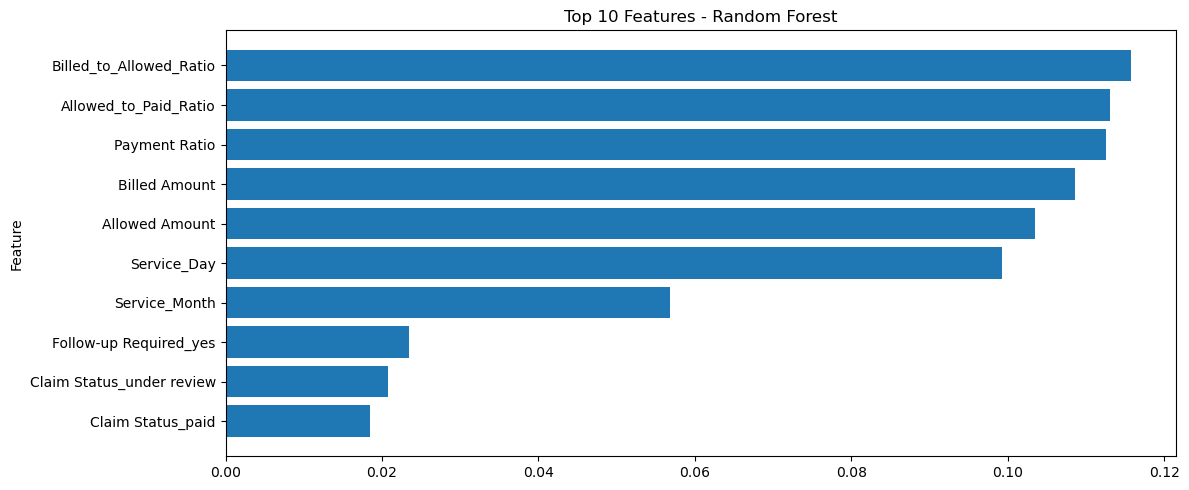

In [27]:
# RF feature importance
feature_importances = rf.feature_importances_

# Creating dataframe
feature_importance_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':feature_importances})

# sort by importance
feature_importance_df = feature_importance_df.sort_values('Importance',ascending=False)

# Plotting the top 10 features
plt.figure(figsize=(12, 5))
plt.barh(feature_importance_df['Feature'][:10],feature_importance_df['Importance'][:10])
plt.ylabel("Feature")
plt.title("Top 10 Features - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Billed_to_Allowed_Ratio, Allowed_to_Paid_Ratio, and Payment Ratio are the top 3 predictors.
#### Billed Amount and Allowed Amount are also features that have strong influences.
#### Model relies on billing metrics with some timing patterns(Service_Day,Service_Month) for outcomes.

#### The random forest model is heavily influenced by financial ratios and amounts, with some influence from date-based features.

# Hyperparameter Tuning for Random Forest

In [28]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
param_grid = {'n_estimators': [50,100,200,300],  
              'max_depth': [10,20,30,None], 
              'min_samples_split': [2,5,10], 
              'min_samples_leaf': [1,2,4], 
              'max_features': ['sqrt','log2',None], 
              'bootstrap': [True,False]}

# Rf model
rf = RandomForestClassifier(random_state=42)

# Randomized search with cross-validation(5-fold)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42)

# Fit for training data
rf_random.fit(X_train_smote,y_train_smote)

# parameters
print("Best Params:",rf_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}


In [29]:
# Train with best parameters
best_rf = rf_random.best_estimator_

# predictions
y_pred_best_rf =best_rf.predict(X_test)

# Evaluate performance
print("Tuned Random Forest Performance:\n", classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Performance:
               precision    recall  f1-score   support

           0       0.40      0.52      0.45        66
           1       0.36      0.22      0.27        72
           2       0.36      0.40      0.38        62

    accuracy                           0.38       200
   macro avg       0.37      0.38      0.37       200
weighted avg       0.37      0.38      0.36       200



#### Recall improved for Denied and Partially Paid, Class 0 and 2 claims. Model improved in identifying denied and paid claims. 
#### Class 1(Paid) is still underperforming. Suggesting there may be overlap(partially paid and other classes) or noise.

# Feature Selection (Top 10)

In [30]:
# Select top 10 features
top_features = ['Billed_to_Allowed_Ratio','Allowed_to_Paid_Ratio','Payment Ratio','Billed Amount','Allowed Amount',
                'Service_Day','Service_Month','Follow-up Required_yes','Claim Status_under review','Claim Status_paid']

# X, y
X_top = df_model[top_features]
y = df_model['Outcome']

# Split 80-20
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42,stratify=y)

In [31]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# distribution
print("SMOTE class distribution:\n",y_train_smote.value_counts(normalize=True))

SMOTE class distribution:
 0    0.333333
2    0.333333
1    0.333333
Name: Outcome, dtype: float64


# XGBoost Baseline (Top 10 Features + SMOTE)

In [32]:
from xgboost import XGBClassifier

# XGBoost baseline model
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42)

# Fit on SMOTE data
xgb.fit(X_train_smote,y_train_smote)

# Predict
y_pred_xgb = xgb.predict(X_test)

# evaluation
print("XGBoost Baseline Performance:\n", classification_report(y_test, y_pred_xgb))

C:\Users\dingg\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:02:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline Performance:
               precision    recall  f1-score   support

           0       0.32      0.36      0.34        66
           1       0.35      0.31      0.33        72
           2       0.30      0.31      0.30        62

    accuracy                           0.33       200
   macro avg       0.33      0.33      0.32       200
weighted avg       0.33      0.33      0.32       200



#### Performance is relatively balanced across all classes. Overall metrics still remain low.
#### Results suggest that the top 10 features alone might not capture enough complexity for XGBoost.

# Hyperparameter Tuning for XGBoost

In [33]:
# Hyperparameter grid
param_grid = param_grid = {'n_estimators': [50, 100, 200, 300],
                           'max_depth': [3, 5, 10, 15],
                           'learning_rate': [0.01, 0.05, 0.1, 0.3],
                           'subsample': [0.6, 0.8, 1.0],
                           'colsample_bytree': [0.6, 0.8, 1.0],
                           'gamma': [0, 1, 5],
                           'reg_lambda': [0, 1, 5],# L2
                           'reg_alpha': [0, 1, 5],# L1
                          }
# Classifier
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42)

In [34]:
# Randomized search
xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1)

In [35]:
# Fitting
xgb_search.fit(X_train_smote, y_train_smote)

# Model
best_xgb = xgb_search.best_estimator_

# predict
y_pred_xgb_tuned = best_xgb.predict(X_test)

# evalutation
print("Tuned XGBoost Performance:\n",classification_report(y_test,y_pred_xgb_tuned))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tuned XGBoost Performance:
               precision    recall  f1-score   support

           0       0.31      0.33      0.32        66
           1       0.45      0.40      0.42        72
           2       0.35      0.37      0.36        62

    accuracy                           0.37       200
   macro avg       0.37      0.37      0.37       200
weighted avg       0.37      0.37      0.37       200



#### XGBoost benefitted from tuning compared to the baseline model.
#### The largest improvement was seen in identifying Class 1 (paid claims) with higher precision/recall.
#### Model is more consistent and balanced across the 3 classes.

# SHAP (Tuned XGBoost)

<Figure size 640x480 with 0 Axes>

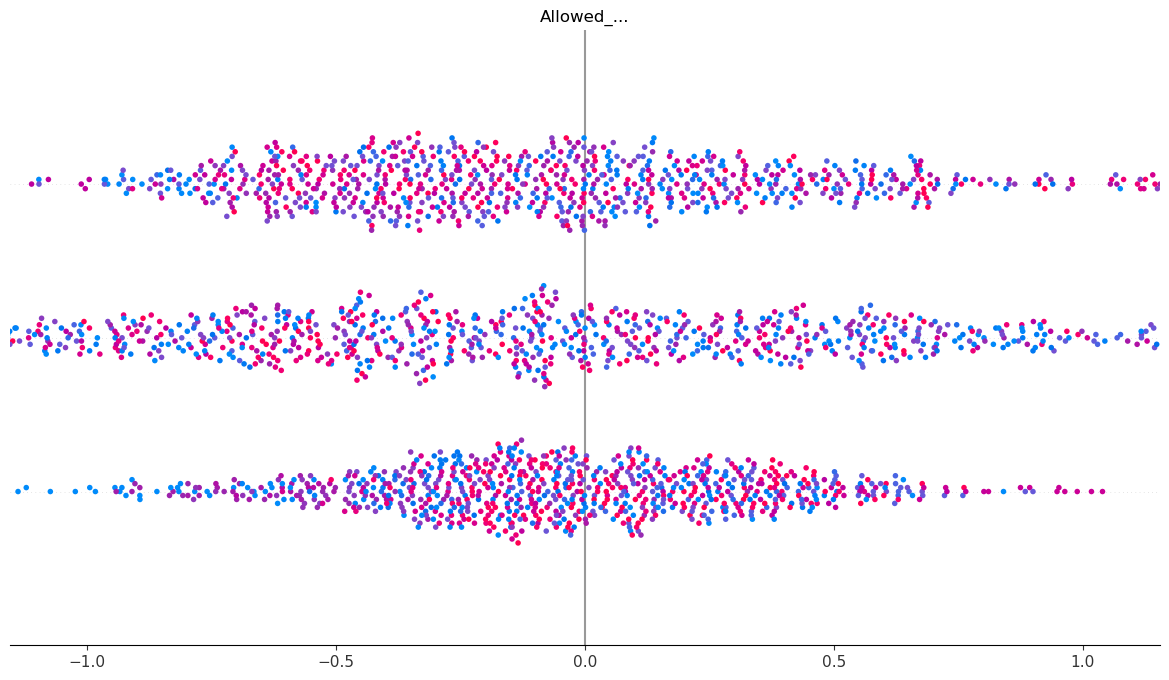

In [36]:
import shap

# Input data copy
X_display =X_train_smote.copy()

# Model
model=best_xgb  

# Initializing through treexplainer/computing
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_display)

# Summary Plots
plt.figure()
shap.summary_plot(shap_values,X_display,plot_type="dot")

#### Billed_to_Allowed_Ratio (Row 1)
#### Allowed_to_Paid_Ratio (Row 2)
#### Payment Ratio (Row 3)

#### For `Billed_to_Allowed_Ratio' high values(red) tend to increase the models output prediction, while low values(blue) push it in the opposite.
#### Similarity is shown for Allowed to Paid and Payment Ratio

#### Billing ratios are the most influential in model prediction.

# Project Summary

#### This project aimed to develop a predictive model that identifies patterns and trends in healthcare claims data, specifically related to uncover cost patterns, identify potential fraud indicators, and classify outcomes. To achieve this, data preprocessing, feature engineering, and model interpretability techniques to optimize model performance.

## Model performance Summary
#### After testing multiple algorithms, such as Logistic Regression, Random Forest, and XGBoost. The tuned XGBoost classifier had the most balanced performance classification metrics.

#### Accuracy: Around 37%
#### Precision/Recall/F-1 Score: Improved consistency across the three classes after hyperparameter tuning was implemented.

## Feature Importance & SHAP
#### The top 3 influential features were 'Billed_To_Amount_Ratio', 'Payment  Ratio', and 'Allowed_to_Paid_Ratio', which are top contributors to the model's decision process.
#### SHAP analysis revealed that higher values of billing ratios increased the likelihood of that specified class prediction. Meaning elevated billing to amount or 'delayed' payment patterns are strong indicators in determining outcomes.
#### These features dominate the model's decision-making across the 3 classes.